<a href="https://colab.research.google.com/github/sileysa/Semester_5/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langkah 1 - Ilustrasi Data Non-Linier

## Langkah 1a - Import Library

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

## Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## Langkah 1c - Buat Data Dummy Non-Linier

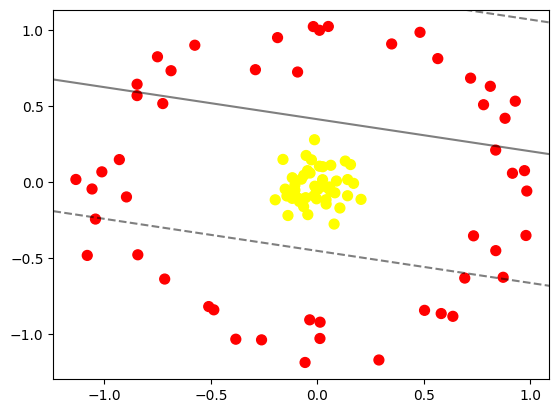

In [3]:
	# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [5]:
r = np.exp(-(X**2).sum(1))

In [6]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.63622643, -0.88444469],
       [-0.75062247,  0.82566017],
       [ 0.06310365,  0.11070529],
       [-0.8464364 ,  0.56999706],
       [-0.14284236, -0.09166586],
       [-0.10600128, -0.0862414 ],
       [-0.01201534, -0.02698314],
       [-0.08410905, -0.12810054],
       [ 0.83767405, -0.45159923],
       [ 0.15562258,  0.11556262],
       [ 0.73325883, -0.35404475],
       [-0.89620251, -0.09778341],
       [-0.02775339,  0.14671888],
       [ 0.78032813,  0.50984258],
       [ 0.02451081,  0.01582747],
       [ 0.04080989, -0.11622446],
       [-0.0132971 ,  0.27922992],
       [-0.18685666,  0.95199451],
       [ 0.20503343, -0.11375637],
       [-0.0896639 , -0.10619681],
       [ 0.01010235,  1.00025804],
       [ 0.00959274,  0.10472985],
       [-0.6869314 ,  0.73387036],
       [ 0.87231274, -0.62715888],
       [ 0.00243246, -0.04776925],
       [ 0.07868836, -0.2765405 ],
       [ 0.0525652 , -0.04237297],
       [ 0.05504188, -0.03517227],
       [-0.1054426 , -0.05275346],
       [-0.11800029, -0.10713183],
       [-0.0576565 , -1.18853808],
       [-0.15103551, -0.04626831],
       [ 0.28899393, -1.17215753],
       [-0.16139632,  0.14940291],
       [ 0.98334269, -0.05892699],
       [ 0.00230055, -0.0320524 ],
       [ 0.71943027,  0.68497047],
       [-0.01625231, -0.09061528],
       [ 0.48195435,  0.98688195],
       [ 0.69203223, -0.63246123],
       [-0.10554721, -0.02037652],
       [ 0.01286936, -0.92295856],
       [ 0.17001582, -0.00829421],
       [-0.00427308, -0.04782445],
       [-0.01892774,  1.02475713],
       [ 0.02531417,  0.1013712 ],
       [ 0.02613555, -0.02692836],
       [-0.06362398,  0.04471175],
       [ 0.04123706, -0.14442456],
       [-0.11763834,  0.02869021],
       [-0.0343599 ,  0.05995429],
       [ 0.9794133 , -0.35173642],
       [-1.08029376, -0.48320033],
       [ 0.14227243,  0.01658642],
       [ 0.05723555, -0.03228419],
       [ 0.50327561, -0.84505978],
       [-0.84291084, -0.47892755],
       [-0.1379687 , -0.22015284],
       [-1.13364459,  0.01731343],
       [ 0.58141554, -0.8661539 ],
       [-0.19781053, -0.11663713],
       [ 0.92935304,  0.53313645],
       [ 0.1418282 , -0.08989171],
       [-1.01177187,  0.06753288],
       [ 0.81206858,  0.63124926],
       [-0.00568825, -0.03150986],
       [-0.57536593,  0.90187081],
       [ 0.10588953, -0.17066172],
       [ 0.0895534 ,  0.00715769],
       [-0.92965695,  0.14823984],
       [-0.07489006,  0.01933179],
       [-1.04175145, -0.24361505],
       [-0.06443991, -0.16152117],
       [ 0.83726287,  0.2108922 ],
       [-0.00377419, -0.11006424],
       [ 0.88125501,  0.42051579],
       [ 0.05148012,  1.02536545],
       [ 0.13113505,  0.13851188],
       [-0.38280863, -1.03516904],
       [ 0.08220215, -0.07057682],
       [-0.04478312, -0.21445724],
       [-0.84634172,  0.64481928],
       [-0.09280174,  0.72530911],
       [ 0.34886511,  0.9102697 ],
       [-0.72570681,  0.5173895 ],
       [ 0.06321409, -0.06043978],
       [ 0.0121358 , -1.03045456],
       [-0.05475096, -0.10273357],
       [-1.05777546, -0.04540312],
       [-0.71676549, -0.63882916],
       [-0.04609207,  0.07541546],
       [ 0.56539355,  0.81369487],
       [-0.05270726,  0.17528386],
       [ 0.97252063,  0.07547256],
       [-0.26201499, -1.03942241],
       [-0.2907959 ,  0.74072495],
       [-0.48612858, -0.84157782],
       [ 0.91599748,  0.05827251],
       [-0.51003587, -0.82007934],
       [-0.03581241, -0.90753115]]), y=array([0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]))>

# Langkah 2 - Fitting Model

In [7]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

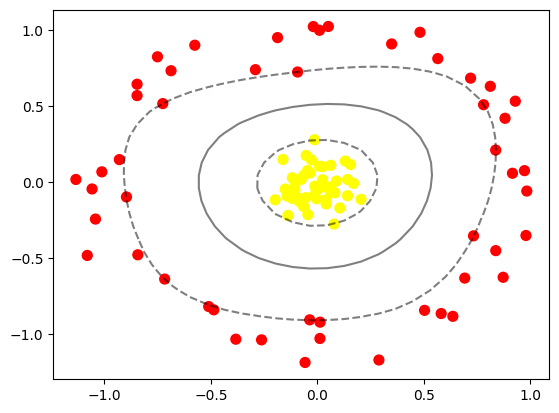

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')